## Importação e visualização da base de dados

In [1]:
# Importando Pandas e Numpy

import pandas as pd
import numpy as np

In [3]:
df = pd.read_excel('engajamento_instagram.xlsx')

In [4]:
df.head()

,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,NaN,Loja,N,N,NaN,2874
1,Foto,2021-09-11,2930,28,NaN,Loja/Produtos,N,N,NaN,2958
2,Foto,2021-09-11,2807,9,NaN,Loja,N,N,NaN,2816
3,Vídeo,2021-09-12,5115,49,82878.0,Produtos,N,N,NaN,5164
4,Foto,2021-09-13,4392,45,NaN,Produtos,S,N,NaN,4437


In [5]:
df.tail()

,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
47,IGTV,2022-03-12,5489,77,17796.0,Dicas de como usar/Novos Produtos,S,N,NaN,5566
48,Foto,2022-03-20,29084,479,NaN,Datas comemorativas/Promoções,S,S,NaN,29563
49,Foto,2022-03-22,9087,106,NaN,NaN,S,S,NaN,9193
50,Foto,2022-03-26,16551,186,NaN,NaN,S,N,NaN,16737
51,IGTV,2022-03-27,4934,65,12627.0,Dicas de como usar/Produtos,S,N,NaN,4999


In [6]:
# Excluindo a coluna Visualizações
df.drop('Visualizações', axis=1, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Tipo         52 non-null     object        
 1   Data         52 non-null     datetime64[ns]
 2   Curtidas     52 non-null     int64         
 3   Comentários  52 non-null     int64         
 4   Tags         44 non-null     object        
 5   Pessoas      52 non-null     object        
 6   Campanhas    52 non-null     object        
 7   Carrossel    8 non-null      object        
 8   Interacoes   52 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 3.8+ KB


In [10]:
# Carrossel possui apenas 8 valores Não Nulos, vamos verificar quais são esses valores.
df['Carrossel'].unique()

array([nan, 'S'], dtype=object)

In [12]:
# Como os 8 valores são "S", vamos preencher os valores nulos com "N"
df.loc[df['Carrossel'].isnull(), 'Carrossel'] = 'N'

In [14]:
df['Carrossel'].value_counts()

Carrossel
N    44
S     8
Name: count, dtype: int64

In [15]:
df.describe()

,Data,Curtidas,Comentários,Interacoes
count,52,52.000000,52.000000,52.000000
mean,2021-12-23 04:36:55.384615424,12262.730769,189.500000,12452.230769
min,2021-09-11 00:00:00,2807.000000,9.000000,2816.000000
25%,2021-10-23 06:00:00,5492.000000,69.500000,5562.500000
50%,2022-01-05 00:00:00,9603.000000,128.000000,9773.500000
75%,2022-02-15 12:00:00,17621.750000,265.250000,17920.750000
max,2022-03-27 00:00:00,37351.000000,852.000000,37853.000000
std,NaN,8165.875326,170.687709,8299.390088


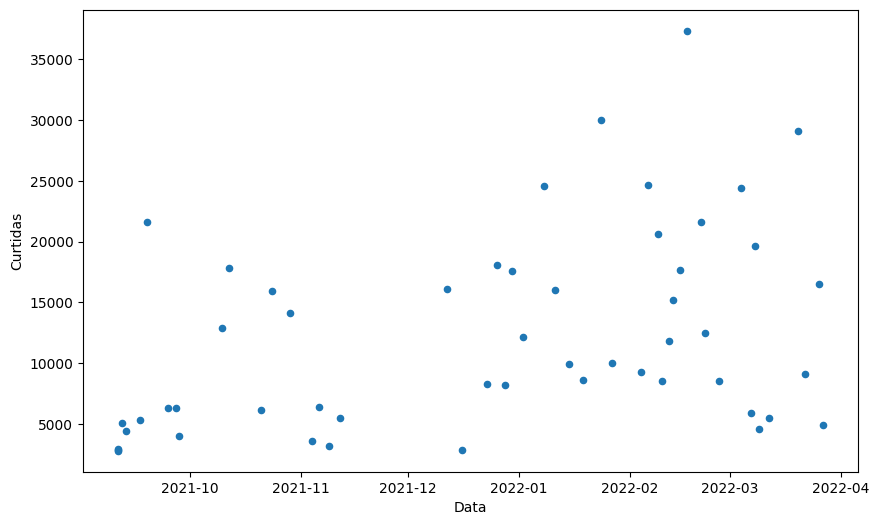

In [16]:
# Um gráfico de dispersão ajudaria a entender melhor curtidas e comentários
df.plot(kind="scatter",x="Data",y="Curtidas",figsize=(10, 6));

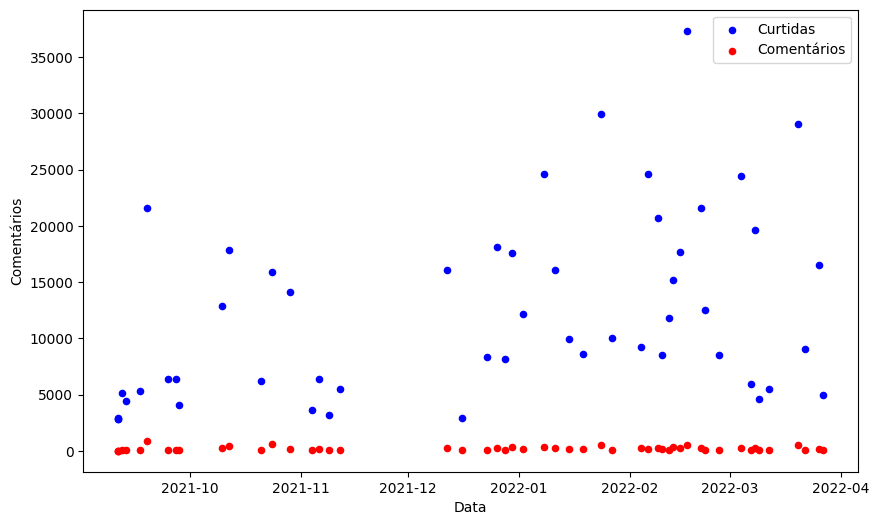

In [17]:
# Podemos colocar curtidas e comentários no mesmo gráfico
ax = df.plot(kind="scatter",x="Data",y="Curtidas",color="blue",label="Curtidas",figsize=(10, 6));
df.plot(kind="scatter",x="Data",y="Comentários",color="red",label="Comentários",figsize=(10, 6),ax=ax);

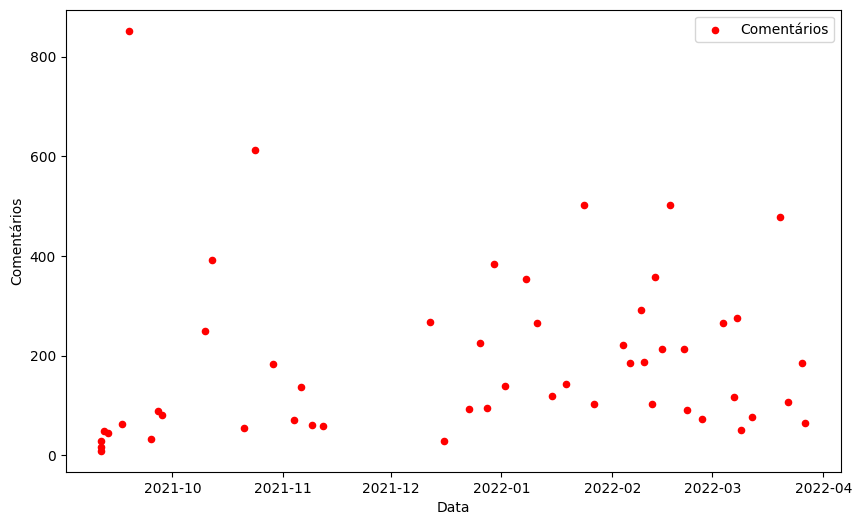

In [18]:
# A escala de curtidas pode estar atrapalhando a visualização, por isso vamos deixar comentários em um gráfico separado
df.plot(kind="scatter",x="Data",y="Comentários",color="red",label="Comentários",figsize=(10, 6));

- O gráfico e as informações estatítiscas não estão dizendo muita coisa pois existe uma grande dispersão entre curtidas e comentários
- Precisamos verificar se existe um padrão usando as outras colunas de informações

### A primeira coisa que podemos fazer é pegar os 5 primeiros registros com mais e menos curtidas

In [21]:
# Ordenando os valores
df.sort_values(by="Curtidas",ascending=False).head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
39,Foto,2022-02-17,37351,502,Promoções,S,S,N,37853
30,Reels,2022-01-24,29981,502,Trends,S,S,N,30483
48,Foto,2022-03-20,29084,479,Datas comemorativas/Promoções,S,S,N,29563
33,Foto,2022-02-06,24655,186,Influenciadores,S,S,N,24841
26,Foto,2022-01-08,24585,354,Datas comemorativas,S,S,S,24939


In [22]:
# Selecionando os 5 últimos valores
df.sort_values(by='Curtidas', ascending= True).head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
2,Foto,2021-09-11,2807,9,Loja,N,N,N,2816
0,Foto,2021-09-11,2858,16,Loja,N,N,N,2874
20,Foto,2021-12-16,2881,29,Produtos,N,N,N,2910
1,Foto,2021-09-11,2930,28,Loja/Produtos,N,N,N,2958
17,Vídeo,2021-11-09,3213,60,Produtos,N,N,N,3273


- Podemos observar que no top 5 todas as postagens, tinham pessoas e eram fotos de campanha
- Nas 5 piores postagens, não haviam pessoas e nem eram postagens de campanhas

- ***Isso pode ser um indicador que pessoas e campanhas tem relação com as curtidas***

In [23]:
# Para melhorar a visualização, vamos criar um padrão no formato dos valores
pd.options.display.float_format = '{:,.2f}'.format

In [25]:
# Agrupando as informações por tipo
df.groupby("Tipo")["Comentários"].count().reset_index()

,Tipo,Comentários
0,Foto,36
1,IGTV,5
2,Reels,5
3,Vídeo,6


In [29]:
# Agrupando por Tipo e Pessoas
df.groupby(["Tipo","Pessoas"])["Curtidas"].mean().reset_index()

,Tipo,Pessoas,Curtidas
0,Foto,N,"3,863.50"
1,Foto,S,"15,236.67"
2,IGTV,S,"6,833.40"
3,Reels,N,"5,934.50"
4,Reels,S,"20,832.00"
5,Vídeo,N,"4,007.50"
6,Vídeo,S,"16,409.50"


In [30]:
df.groupby(["Tipo","Pessoas"])[["Curtidas",'Comentários']].mean().reset_index()

,Tipo,Pessoas,Curtidas,Comentários
0,Foto,N,"3,863.50",29.50
1,Foto,S,"15,236.67",226.20
2,IGTV,S,"6,833.40",133.60
3,Reels,N,"5,934.50",98.00
4,Reels,S,"20,832.00",342.00
5,Vídeo,N,"4,007.50",65.25
6,Vídeo,S,"16,409.50",370.00


In [32]:
# Incluindo a coluna de campanhas
df.groupby(['Tipo', 'Pessoas', 'Campanhas'])[['Curtidas', 'Comentários']].mean().reset_index()

,Tipo,Pessoas,Campanhas,Curtidas,Comentários
0,Foto,N,N,"2,869.00",20.50
1,Foto,N,S,"5,852.50",47.50
2,Foto,S,N,"10,815.29",159.93
3,Foto,S,S,"19,105.38",284.19
4,IGTV,S,N,"6,833.40",133.60
5,Reels,N,N,"5,934.50",98.00
6,Reels,S,N,"12,894.00",249.00
7,Reels,S,S,"24,801.00",388.50
8,Vídeo,N,N,"4,007.50",65.25
9,Vídeo,S,S,"16,409.50",370.00


- O groupby já permite ver que publicações de campanha tem um grande engajamento e com foto de pessoas também

- **Podemos então fazer os agrupamentos que acharmos melhor para entender os nossos dados**

In [33]:
# Somente para pessoas
df.groupby("Pessoas")[["Curtidas", 'Comentários']].mean()

,Curtidas,Comentários
Pessoas,,
N,"4,256.67",52.83
S,"14,664.55",230.50


Postagens com pessoas engajam muito mais para essa marca, sendo 3 vezes maior de quando não tem pessoas

- **Somente para as postagens de campanhas**

In [34]:
# Somente para campanhas
df.groupby('Campanhas')[['Curtidas', 'Comentários']].mean()

,Curtidas,Comentários
Campanhas,,
N,"7,928.33",123.17
S,"18,173.27",279.95


Quando é uma postagem de campanha, o engajamento também é melhor!

In [35]:
# Observação: Carrossel (sem filtrar a base) --> ESTÁ ERRADA A COMPARAÇÃO
df.groupby(df['Carrossel'])[['Curtidas', 'Comentários']].mean()

,Curtidas,Comentários
Carrossel,,
N,"12,343.61",198.43
S,"11,817.88",140.38


In [36]:
# Podemos também filtrar a base
df[df['Tipo'] == 'Foto'].groupby(["Carrossel"])[["Curtidas", "Comentários"]].mean()

,Curtidas,Comentários
Carrossel,,
N,"13,776.36",208.57
S,"11,817.88",140.38


- ***A média sem usar carrossel é melhor do que quando usamos, então não é algo que possa impactar tanto no resultado das mídias dessa empresa olhando inicialmente***

- Nesse caso devemos filtrar apenas as fotos pois só temos carrossel em fotos. Sem esse filtro estaríamos comparando coisas erradas

In [38]:
# Agregando por pessoas e campanhas
df.groupby(['Pessoas', 'Campanhas'])[['Curtidas', 'Comentários']].mean().reset_index()

,Pessoas,Campanhas,Curtidas,Comentários
0,N,N,"3,937.50",53.90
1,N,S,"5,852.50",47.50
2,S,N,"9,923.75",157.80
3,S,S,"19,405.35",303.20


- A média quando tem pessoas E é publicação de campanhas é de cerca de **19,4 mil curtidas**, já quando é apenas pessoas (sem campanha passa para quase 10 mil e se não tiver pessoas chega no máximo a 5,9 mil mesmo em campanhas)

- Nesse caso a gente já consegue mostrar para a empresa a importância de incluir pessoas usando os seus produtos, o que gera um aumento considerável no engajamento

In [40]:
# Agregando por pessoas, campanhas e tipo
df.groupby(['Pessoas', 'Campanhas', 'Tipo'])[['Curtidas', 'Comentários']].mean().reset_index()

,Pessoas,Campanhas,Tipo,Curtidas,Comentários
0,N,N,Foto,"2,869.00",20.50
1,N,N,Reels,"5,934.50",98.00
2,N,N,Vídeo,"4,007.50",65.25
3,N,S,Foto,"5,852.50",47.50
4,S,N,Foto,"10,815.29",159.93
5,S,N,IGTV,"6,833.40",133.60
6,S,N,Reels,"12,894.00",249.00
7,S,S,Foto,"19,105.38",284.19
8,S,S,Reels,"24,801.00",388.50
9,S,S,Vídeo,"16,409.50",370.00


- Analisando novamente a questão do vídeo, ele não parece mais tão ruim assim. Quando feito em campanha e usando pessoas ele teve um resultado bom, inclusive próximo a foto

- O que poderia ter levado a média baixa é que só temos vídeo ou COM pessoa e COM campanha ou sem nenhum dos dois. Não temos nenhum vídeo com apenas um dos dois (pessoa ou campanha)

- Já IGTV, mesmo tendo pessoa, não teve um resultado tão bom

**Inclusive podemos entender o que havia gerado a média baixo no vídeo**

In [41]:
# Vamos filtrar a base apenas onde o tipo é Vídeo
df[df['Tipo'] == 'Vídeo']

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
3,Vídeo,2021-09-12,5115,49,Produtos,N,N,N,5164
9,Vídeo,2021-09-28,4056,81,Produtos,N,N,N,4137
15,Vídeo,2021-11-04,3646,71,Produtos,N,N,N,3717
17,Vídeo,2021-11-09,3213,60,Produtos,N,N,N,3273
24,Vídeo,2021-12-30,17600,383,Trends,S,S,N,17983
37,Vídeo,2022-02-13,15219,357,Datas comemorativas,S,S,N,15576


- Aqui percebemos que a loja tentou postar 4 vídeos mostrando seus produtos (sem nenhuma pessoa) e o resultado foi baixo. Quando o vídeo foi feito com pessoas aproveitando trends e datas comemorativas o resultado foi muito bom!

## Vamos analisar agora como se comportam as Tags

In [42]:
df.groupby('Tags')['Curtidas'].mean().reset_index()

,Tags,Curtidas
0,Datas comemorativas,"17,975.00"
1,Datas comemorativas/Promoções,"29,084.00"
2,Dicas de como usar/Novos Produtos,"5,703.50"
3,Dicas de como usar/Produtos,"7,586.67"
4,Influenciadores,"15,197.29"
5,Loja,"2,832.50"
6,Loja/Produtos,"2,930.00"
7,Novos Produtos,"11,619.57"
8,Produtos,"5,666.92"
9,Promoções,"26,645.50"


**Para conseguir analisar separadamente as tags, podemos dividir linhas com 2 tags**

- Primeiro vamos usar o split para separar em uma lista com as tags

- depois vamos utilizar o explode para transformar as listas com 2 tags em 2 linhas diferentes

In [45]:
df['Tags'] = df['Tags'].str.split('/')
df.head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,[Loja],N,N,N,2874
1,Foto,2021-09-11,2930,28,"[Loja, Produtos]",N,N,N,2958
2,Foto,2021-09-11,2807,9,[Loja],N,N,N,2816
3,Vídeo,2021-09-12,5115,49,[Produtos],N,N,N,5164
4,Foto,2021-09-13,4392,45,[Produtos],S,N,N,4437


In [46]:
df = df.explode('Tags')
df.head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,Loja,N,N,N,2874
1,Foto,2021-09-11,2930,28,Loja,N,N,N,2958
1,Foto,2021-09-11,2930,28,Produtos,N,N,N,2958
2,Foto,2021-09-11,2807,9,Loja,N,N,N,2816
3,Vídeo,2021-09-12,5115,49,Produtos,N,N,N,5164


In [48]:
df.groupby('Tags')['Curtidas'].mean().reset_index()

,Tags,Curtidas
0,Datas comemorativas,"20,752.25"
1,Dicas de como usar,"6,833.40"
2,Influenciadores,"15,197.29"
3,Loja,"2,865.00"
4,Novos Produtos,"10,304.89"
5,Produtos,"6,269.82"
6,Promoções,"27,458.33"
7,Trends,"20,024.00"


In [51]:
df.groupby('Tags')[['Curtidas', 'Comentários']].mean().sort_values('Curtidas', ascending=False).reset_index()

,Tags,Curtidas,Comentários
0,Promoções,"27,458.33",531.00
1,Datas comemorativas,"20,752.25",343.50
2,Trends,"20,024.00",352.25
3,Influenciadores,"15,197.29",161.71
4,Novos Produtos,"10,304.89",198.56
5,Dicas de como usar,"6,833.40",133.60
6,Produtos,"6,269.82",94.12
7,Loja,"2,865.00",17.67


- Postagens de promoções são as que mais engajam

- Além de promoções, Datas Comemorativas e Trends são as que mais engajam

In [52]:
# Filtrando valores sem tags
df[df['Tags'].isnull()]

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
11,Foto,2021-10-12,17831,391,NaN,S,S,N,18222
19,Foto,2021-12-12,16086,268,NaN,S,S,N,16354
29,Foto,2022-01-19,8612,142,NaN,S,N,N,8754
38,Foto,2022-02-15,17687,213,NaN,S,N,N,17900
41,Foto,2022-02-22,12530,90,NaN,S,N,N,12620
43,Foto,2022-03-04,24399,266,NaN,S,S,N,24665
49,Foto,2022-03-22,9087,106,NaN,S,S,N,9193
50,Foto,2022-03-26,16551,186,NaN,S,N,N,16737


In [53]:
df.loc[df['Tags'].isnull(), 'Tags'] = 'Sem tag'

In [55]:
df['Tags'].value_counts()

Tags
Produtos               17
Novos Produtos          9
Sem tag                 8
Influenciadores         7
Dicas de como usar      5
Datas comemorativas     4
Trends                  4
Loja                    3
Promoções               3
Name: count, dtype: int64

In [56]:
df.groupby('Tags')[['Curtidas', 'Comentários']].mean().sort_values('Curtidas', ascending=False).reset_index()

,Tags,Curtidas,Comentários
0,Promoções,"27,458.33",531.00
1,Datas comemorativas,"20,752.25",343.50
2,Trends,"20,024.00",352.25
3,Sem tag,"15,347.88",207.75
4,Influenciadores,"15,197.29",161.71
5,Novos Produtos,"10,304.89",198.56
6,Dicas de como usar,"6,833.40",133.60
7,Produtos,"6,269.82",94.12
8,Loja,"2,865.00",17.67


In [58]:
df.groupby(['Pessoas','Tags'])[['Curtidas', 'Comentários']].mean().sort_values('Curtidas', ascending=False).reset_index()

,Pessoas,Tags,Curtidas,Comentários
0,S,Promoções,"27,458.33",531.00
1,S,Datas comemorativas,"20,752.25",343.50
2,S,Trends,"20,024.00",352.25
3,S,Sem tag,"15,347.88",207.75
4,S,Influenciadores,"15,197.29",161.71
5,S,Novos Produtos,"10,923.12",215.62
6,S,Produtos,"8,316.38",131.62
7,S,Dicas de como usar,"6,833.40",133.60
8,N,Novos Produtos,"5,359.00",62.00
9,N,Produtos,"4,450.67",60.78


In [59]:
df.groupby(['Campanhas','Tags'])[['Curtidas', 'Comentários']].mean().sort_values('Curtidas', ascending=False).reset_index()

,Campanhas,Tags,Curtidas,Comentários
0,S,Promoções,"33,217.50",490.50
1,S,Trends,"22,400.67",386.67
2,S,Datas comemorativas,"20,752.25",343.50
3,S,Influenciadores,"18,715.40",197.60
4,S,Sem tag,"16,850.75",257.75
5,N,Promoções,"15,940.00",612.00
6,N,Sem tag,"13,845.00",157.75
7,N,Trends,"12,894.00",249.00
8,S,Novos Produtos,"11,040.67",323.00
9,N,Novos Produtos,"9,937.00",136.33


## Conclusões

- **Ter o rosto de outras pessoas é fundamental para um bom enganjamento na publicação.**
    - Em todas as tags, quando havia uma pessoa, o resultado foi muito melhor.

- **Criar campanhas ajudam muito na divulgação da marca**

- **Promoções tiveram um desempendo absurdamente maior que qualquer outra tag.**
    - Porém pe uma tag que pode ter custo para a loja, o que deve ser analisado.

- **Usar conteúdos que estão em trend também ajudam na divulgação da marca, mesmo sendo a trend sendo de outros nichos.**

- **A melhor maneira de mostrar os produtos é através de outras pessoas e, se possível, em campanhas de datas especiais.**

- **Para novos produtos a inclusão de pessoas é mais crítica ainda, sendo quase o dobro quando há um rosto junto ao produto.**

- **Não podemos afirmar que a tag *Loja* é ruim até testarmos essa tag incluindo pessoas ou em uma campanha.**

- **Continuaremos a monitorar as postagens para encontrar novos padrões, dado que ainda temo poucas informações de base.**